In [1]:
from scr.qsvdd_core.circuits import QSVDDCircuit
import numpy as np
from qiskit import transpile, QuantumCircuit
from qclib.util import get_cnot_count
import pennylane as qml
from matplotlib import pyplot as plt

In [2]:
n_qubits = 5
amplitudes = np.random.rand(32)
amplitudes /= np.linalg.norm(amplitudes)
# amplitudes = np.pad(amplitudes, (0, 32 - len(amplitudes)), mode='constant')
params = np.random.rand(14)
print(amplitudes)

[0.09998541 0.13166325 0.2155109  0.06939471 0.29530313 0.24794473
 0.00861924 0.29354382 0.12404042 0.20911992 0.0721621  0.12451175
 0.1337351  0.19324457 0.22083205 0.18424157 0.13852736 0.05821369
 0.18128963 0.24280418 0.11813622 0.04447488 0.16701425 0.21028458
 0.30182317 0.2885297  0.074307   0.06733813 0.20227941 0.15659368
 0.04404899 0.12036988]


In [3]:
n_qubits = 5 # 5 para Credit Card, 8 para MNIST/FMNIST
n_features = 2**n_qubits

amplitudes = np.random.rand(n_features)
amplitudes /= np.linalg.norm(amplitudes)

params_map = {
    "qcnn": 375,
    "lcqhnn": 5,
    "qae": 48
}

print(f"--- Extraindo métricas de Hardware para {n_qubits} Qubits ---")

for ansatz in ["qcnn", "qae", "lcqhnn"]:

    # A. O device precisa usar o n_qubits correto
    dev = qml.device('default.qubit', wires=n_qubits)

    # B. O QNode recebe a variável `ansatz` dinamicamente do loop
    @qml.qnode(dev)
    def check_circuit(amplitude_array, params_array):
        q_circuit = QSVDDCircuit(n_qubits)
        q_circuit.qc_complete_design(amplitude_array, params_array, f_method="pennylane", ansatz_type=ansatz)
        return qml.state()

    # C. Cria a função de inspeção
    specs_function = qml.specs(check_circuit)

    # D. Pega o número de parâmetros e cria o dummy
    n_params = params_map[ansatz]
    params = np.random.rand(n_params)

    # E. Roda a inspeção
    specs = specs_function(amplitudes, params)
    resources = specs["resources"]

    # F. Acessa os dados
    gate_types = resources.gate_types

    # Soma as portas CNOT e CZ para ter o total de portas de emaranhamento
    n_cnots = gate_types.get("CNOT", 0)
    n_czs = gate_types.get("CZ", 0)
    total_entangling = n_cnots + n_czs

    depth = resources.depth

    # Imprime no formato da tabela
    print(f"{ansatz.upper():<8} -> Portas 2-Qubits (CNOT/CZ): {total_entangling:<4} | Profundidade: {depth}")

--- Extraindo métricas de Hardware para 5 Qubits ---
QCNN     -> Portas 2-Qubits (CNOT/CZ): 57   | Profundidade: 82
QAE      -> Portas 2-Qubits (CNOT/CZ): 81   | Profundidade: 65
LCQHNN   -> Portas 2-Qubits (CNOT/CZ): 8    | Profundidade: 11


In [4]:
print(qml.io.plugin_converters.keys())

dict_keys([])


In [5]:
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

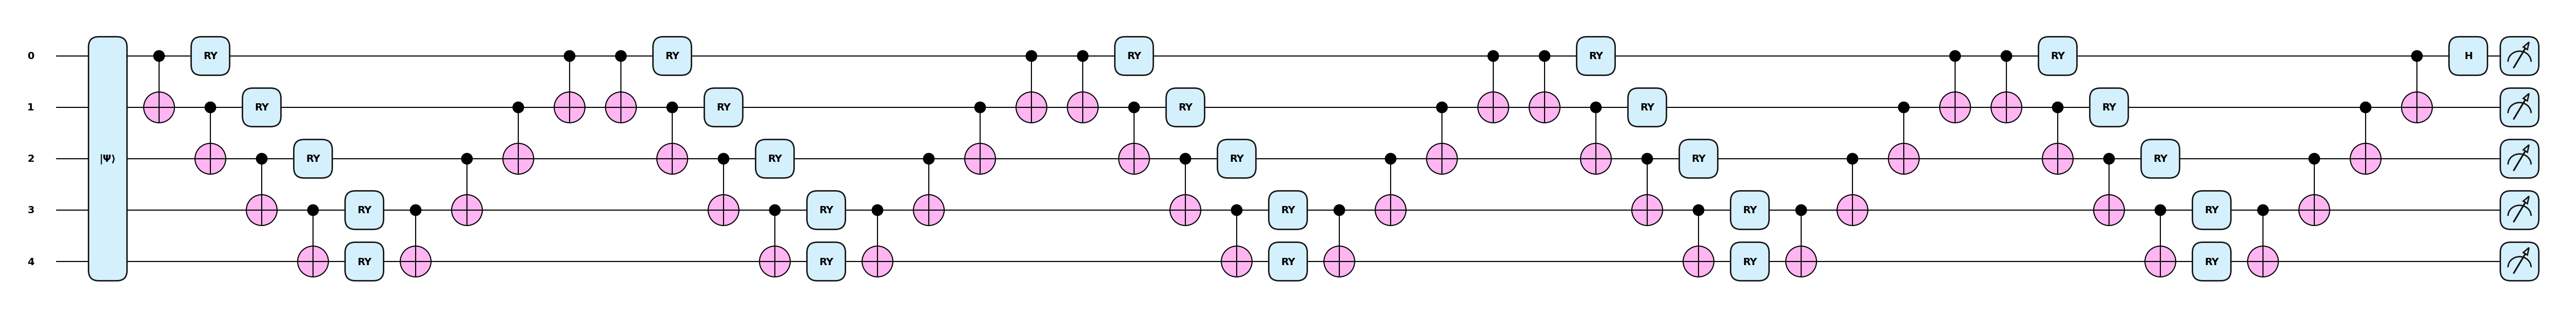

In [6]:
dev = qml.device('default.qubit', wires = 5)
@qml.qnode(dev)
def check_circuit(amplitude_array, params):
    q_circuit = QSVDDCircuit(n_qubits)
    q_circuit.qc_complete_design(amplitude_array, params, f_method="pennylane")
    return qml.state()

qml.drawer.use_style("pennylane")
fig, ax = qml.draw_mpl(check_circuit)(amplitudes, params)

plt.show()

In [ ]:
# Device configuration for the benchmark
dev_bench = qml.device('default.qubit', wires=n_qubits)

def get_specs_for_method(method_name, amplitudes):
    """Generates a temporary QNode to extract metrics for a specific method."""
    @qml.qnode(dev_bench)
    def temp_circuit():
        q_circuit = QSVDDCircuit(n_qubits=n_qubits)
        mapping_fn = q_circuit.feature_mapping(amplitudes, method=method_name)
        mapping_fn(wires=range(5))
        return qml.state()

    # Extract resources using the new PennyLane framework
    info = qml.specs(temp_circuit)()
    return info["resources"]

# --- Benchmark Execution ---

methods_map = {
    "BAA LowRank":          "baa_lowrank",
    "Bidirectional":        "bdsp",
    "Divide and Conquer":   "dcsp",
    "Isometry":             "isometry",
    "Qiskit Native":        "qiskit",
    "UCGE":                 "ucge",
}

header = f" QUANTUM FEATURE MAPPING BENCHMARKS "
print(f"\n{header:=^75}")
print(f"{'Method Strategy':<25} | {'CNOTs':>8} | {'Depth':>8} | {'Total Gates':>12}")
print("-" * 75)

all_results = {}

for name, method_key in methods_map.items():
    try:
        res = get_specs_for_method(method_key, amplitudes)
        all_results[name] = res

        # Search for CNOT or CX in the gate types dictionary
        cnot_count = res.gate_types.get("CNOT", 0) + res.gate_types.get("CX", 0)

        print(f"{name:<25} | {cnot_count:>8} | {res.depth:>8} | {res.num_gates:>12}")
    except Exception as e:
        print(f"{name:<25} | Error processing method: {str(e)[:30]}...")

print("-" * 75)

In [ ]:
# --- Gate Breakdown ---
print(f"\n{' GATE BREAKDOWN BY METHOD ':-^75}")

for name, res in all_results.items():
    gates_str = ", ".join([f"{gate}({count})" for gate, count in res.gate_types.items()])
    print(f"- {name:<23} -> {gates_str}")

print("=" * 75)

In [ ]:
dev = qml.device('default.qubit', wires = 5)
@qml.qnode(dev)
def check_ansatz_circuit(params):
    q_circuit = ProposedVQC(n_qubits)
    q_circuit.proposed_ansatz(params)
    return qml.state()


qml.drawer.use_style("pennylane")
fig, ax = qml.draw_mpl(check_ansatz_circuit)(params)
fig.set_size_inches(10, 5)
plt.show()

In [ ]:
dev = qml.device('default.qubit', wires = 5)
@qml.qnode(dev)
def check_feature_mapping_circuit(amplitude_array):
    q_circuit = QSVDDCircuit(n_qubits)
    mapping_fn = q_circuit.feature_mapping(amplitude_array, method="baa_lowrank")
    mapping_fn(wires=range(n_qubits))
    return qml.state()

qml.drawer.use_style("pennylane")
fig, ax = qml.draw_mpl(check_feature_mapping_circuit)(amplitudes)

plt.show()

In [ ]:
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def cost_circuit(data):
    qml.AmplitudeEmbedding(data, wires=range(n_qubits), normalize=True)
    return qml.state()

tape = qml.workflow.construct_tape(cost_circuit)(amplitudes)

expanded_tape = tape.expand(
    depth=5,
    stop_at=lambda obj: obj.name in ["CNOT", "RY", "RZ", "RX"]
)

gate_counts = {}
for op in expanded_tape.operations:
    gate_counts[op.name] = gate_counts.get(op.name, 0) + 1

print("--- Actual Count (Decomposed) ---")
for gate, count in gate_counts.items():
    print(f"{gate}: {count}")